# SFT — Fine-tuning com GPT-2 Large

Notebook de pós-treino (Supervised Fine-Tuning) usando os artefatos preparados no notebook anterior.

**Modelo:** `gpt2-large` (774 M parâmetros)  
**Hardware alvo:** RTX 3050 6 GB / Colab T4 16 GB  
**Template:** Phi-3 (`<|user|>` / `<|assistant|>`)  

Pipeline:
1. Carrega artefatos do notebook de preparação
2. Instancia GPT-2 Large com cabeça LM
3. Redimensiona embedding para incluir tokens especiais
4. Loop de treino com `float16`, gradient accumulation e checkpoint
5. Plota curvas de loss treino/validação
6. Geração de respostas antes e depois do fine-tuning
7. Salva modelo fine-tuned

## 0. Instalação

In [1]:
!uv add transformers torch matplotlib tqdm

Resolved 175 packages in 1ms
Audited 155 packages in 7ms


## 1. Imports e hiperparâmetros

In [3]:
import json, math, time
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, GPT2LMHeadModel, GPT2Config
from tqdm.auto import tqdm

# ── Reprodutibilidade ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)

# ── Caminhos ──────────────────────────────────────────────────────────────────
ARTIFACTS_DIR = Path("sft_artifacts")   # gerado pelo notebook de preparação
OUTPUT_DIR    = Path("sft_model")       # onde o modelo fine-tuned será salvo
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Modelo ────────────────────────────────────────────────────────────────────
MODEL_NAME      = "gpt2-large"   # 774 M parâmetros — melhor custo-benefício
                                  # para RTX 3050 6 GB com float16

# ── Hiperparâmetros de treino ─────────────────────────────────────────────────
NUM_EPOCHS          = 3       
BATCH_SIZE          = 2       # reduzir para 2 se OOM
GRAD_ACCUM_STEPS    = 2       # batch efetivo = BATCH_SIZE * GRAD_ACCUM_STEPS = 8
LEARNING_RATE       = 5e-5    # taxa clássica para SFT de GPT-2
WEIGHT_DECAY        = 0.01
WARMUP_RATIO        = 0.1     # 10% dos steps para warmup linear
MAX_GRAD_NORM       = 1.0     # gradient clipping
EVAL_EVERY_N_STEPS  = 50      # frequência de avaliação no val set
ALLOWED_MAX_LEN     = 512
PAD_TOKEN_ID        = 50256
IGNORE_INDEX        = -100
USE_FP16            = True    # float16: economiza ~50% de VRAM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   VRAM total: {total:.1f} GB")

✅ Device: cuda
   GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
   VRAM total: 6.4 GB


## 2. Carrega artefatos do notebook de preparação

In [4]:
checkpoint = torch.load(ARTIFACTS_DIR / "processed_dataset.pt", map_location="cpu")
train_data = checkpoint["train"]
val_data   = checkpoint["val"]
test_data  = checkpoint["test"]
cfg        = checkpoint["config"]

tokenizer = AutoTokenizer.from_pretrained(ARTIFACTS_DIR / "tokenizer")
tokenizer.pad_token_id = PAD_TOKEN_ID

USER_TOKEN_ID      = cfg["user_token_id"]
ASSISTANT_TOKEN_ID = cfg["assistant_token_id"]

print(f"✅ Artefatos carregados")
print(f"   treino    : {len(train_data)} amostras")
print(f"   validação : {len(val_data)} amostras")
print(f"   teste     : {len(test_data)} amostras")
print(f"   vocab size: {len(tokenizer)}")

✅ Artefatos carregados
   treino    : 850 amostras
   validação : 100 amostras
   teste     : 50 amostras
   vocab size: 50259


## 3. Dataset e DataLoaders

In [5]:
class InstructionDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s = self.data[idx]
        return {
            "input_ids":      s["input_ids"],
            "target_ids":     s["target_ids"],
            "attention_mask": s["attention_mask"],
        }


def collate_fn(batch):
    """Padding dinâmico: preenche apenas até o maior exemplo do batch."""
    max_len = max(s["attention_mask"].sum().item() for s in batch)
    iids, tids, masks = [], [], []
    for s in batch:
        real = s["attention_mask"].sum().item()
        pad  = max_len - real
        iids.append(torch.cat([s["input_ids"][:real],
                                torch.full((pad,), PAD_TOKEN_ID, dtype=torch.long)]))
        tids.append(torch.cat([s["target_ids"][:real],
                                torch.full((pad,), IGNORE_INDEX,  dtype=torch.long)]))
        masks.append(torch.cat([s["attention_mask"][:real],
                                 torch.zeros(pad, dtype=torch.long)]))
    return {
        "input_ids":      torch.stack(iids),
        "target_ids":     torch.stack(tids),
        "attention_mask": torch.stack(masks),
    }


train_loader = DataLoader(InstructionDataset(train_data), batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          pin_memory=(DEVICE.type=="cuda"))
val_loader   = DataLoader(InstructionDataset(val_data),   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          pin_memory=(DEVICE.type=="cuda"))
test_loader  = DataLoader(InstructionDataset(test_data),  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          pin_memory=(DEVICE.type=="cuda"))

print(f"✅ DataLoaders prontos")
print(f"   train: {len(train_loader)} batches | val: {len(val_loader)} | test: {len(test_loader)}")

✅ DataLoaders prontos
   train: 425 batches | val: 50 | test: 25


## 4. Carrega GPT-2 Large e redimensiona embeddings

In [6]:
print(f"⏳ Baixando {MODEL_NAME}...")
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)

# Redimensiona a camada de embedding para incluir os tokens especiais
# adicionados ao tokenizer (<|user|>, <|assistant|>)
# Novos embeddings são inicializados com a média dos existentes
old_vocab  = model.config.vocab_size
new_vocab  = len(tokenizer)
if new_vocab != old_vocab:
    model.resize_token_embeddings(new_vocab)
    # Inicializa novos embeddings como média dos existentes (melhor que zeros)
    with torch.no_grad():
        mean_emb = model.transformer.wte.weight[:old_vocab].mean(dim=0)
        model.transformer.wte.weight[old_vocab:] = mean_emb
    print(f"   Embedding redimensionado: {old_vocab} → {new_vocab}")

model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modelo carregado: {MODEL_NAME}")
print(f"   parâmetros totais    : {n_params:,}")
print(f"   parâmetros treináveis: {n_train:,}")

# Estimativa de VRAM
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    alloc = torch.cuda.memory_allocated() / 1e9
    print(f"   VRAM alocada (modelo): {alloc:.2f} GB")

⏳ Baixando gpt2-large...


c:\Users\raffa\Documents\UFPI\Tópicos em IA\RAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\raffa\.cache\huggingface\hub\models--gpt2-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 436/436 [00:00<00:00, 6806.58it/s]
[transformers] The new embeddings wi

   Embedding redimensionado: 50257 → 50259
✅ Modelo carregado: gpt2-large
   parâmetros totais    : 774,032,640
   parâmetros treináveis: 774,032,640
   VRAM alocada (modelo): 3.17 GB


## 5. Geração de baseline (ANTES do fine-tuning)

Registra as respostas do modelo **antes** do treino para comparação posterior.

In [7]:
USER_TOKEN      = "<|user|>"
ASSISTANT_TOKEN = "<|assistant|>"
END_TOKEN       = "<|endoftext|>"


def generate_response(model, tokenizer, instruction, input_text="",
                      max_new_tokens=200, temperature=0.7, top_p=0.9):
    """Gera uma resposta usando o template Phi-3."""
    user_part = instruction + (f"\n{input_text}" if input_text else "")
    prompt    = f"{USER_TOKEN}\n{user_part}\n{ASSISTANT_TOKEN}\n"

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

    model.eval()
    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=PAD_TOKEN_ID,
            eos_token_id=PAD_TOKEN_ID,   # para no <|endoftext|>
        )

    # Extrai apenas os tokens gerados (após o prompt)
    generated = output[0, input_ids.shape[1]:]
    text = tokenizer.decode(generated, skip_special_tokens=True)

    # Remove qualquer vazamento do próximo turno
    for stop in [USER_TOKEN, ASSISTANT_TOKEN, END_TOKEN]:
        if stop in text:
            text = text[:text.index(stop)]

    return text.strip()


# Perguntas de referência para avaliação qualitativa
TEST_QUESTIONS = [
    "O que é uma árvore AVL e por que ela é preferida em relação a uma BST simples?",
    "Explique o algoritmo QuickSort e sua complexidade de tempo.",
    "Qual a diferença entre processos e threads em sistemas operacionais?",
    "O que é normalização em banco de dados relacionais?",
    "Como funciona o protocolo TCP/IP na camada de transporte?",
]

print("=" * 60)
print("RESPOSTAS ANTES DO FINE-TUNING (baseline)")
print("=" * 60)

baseline_responses = []
for q in TEST_QUESTIONS:
    resp = generate_response(model, tokenizer, q)
    baseline_responses.append({"question": q, "response": resp})
    print(f"\nQ: {q}")
    print(f"A: {resp[:300]}{'...' if len(resp) > 300 else ''}")
    print("-" * 40)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


RESPOSTAS ANTES DO FINE-TUNING (baseline)

Q: O que é uma árvore AVL e por que ela é preferida em relação a uma BST simples?
A: The question is: how can we use this to improve the quality of the code?
Avanto único em relação de um relação
Avanto que é uma AVL e por que ela é preferida em relação a uma BST simples?
Avanto que é uma AVL e por que ela é preferida em relação a uma BST simples?
Avanto que é uma AVL e por que ela ...
----------------------------------------

Q: Explique o algoritmo QuickSort e sua complexidade de tempo.
A: The search for a simple, short, and easy to understand algorithm.
Explique o algoritmo QuickSort e sua complexidade de tempo.
The search for a simple, short, and easy to understand algorithm.
Explique o algoritmo QuickSort e sua complexidade de tempo.
The search for a simple, short, and easy to unde...
----------------------------------------

Q: Qual a diferença entre processos e threads em sistemas operacionais?
A: Lá que también lleva a través de que pa

## 6. Configuração do otimizador e scheduler

In [8]:
from transformers import get_linear_schedule_with_warmup

total_steps   = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

# AdamW com weight decay apenas nos pesos (não nos biases e layer norms)
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped = [
    {"params": [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     "weight_decay": WEIGHT_DECAY},
    {"params": [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     "weight_decay": 0.0},
]
optimizer = torch.optim.AdamW(optimizer_grouped, lr=LEARNING_RATE)

# Linear warmup seguido de decay linear até 0
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# Scaler para mixed precision (float16)
scaler = torch.cuda.amp.GradScaler(enabled=(USE_FP16 and DEVICE.type == "cuda"))

print(f"✅ Otimizador: AdamW  lr={LEARNING_RATE}  wd={WEIGHT_DECAY}")
print(f"   total_steps  : {total_steps}")
print(f"   warmup_steps : {warmup_steps}")
print(f"   float16      : {USE_FP16 and DEVICE.type == 'cuda'}")

✅ Otimizador: AdamW  lr=5e-05  wd=0.01
   total_steps  : 636
   warmup_steps : 63
   float16      : True


C:\Users\raffa\AppData\Local\Temp\ipykernel_23816\4158874896.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_FP16 and DEVICE.type == "cuda"))


## 7. Funções auxiliares de treino e avaliação

In [9]:
def compute_loss(model, batch):
    """
    Calcula a cross-entropy loss mascarada.
    A função nn.CrossEntropyLoss ignora automaticamente os tokens -100
    (IGNORE_INDEX) no target — exatamente os tokens de instrução mascarados
    no notebook de preparação.
    """
    input_ids      = batch["input_ids"].to(DEVICE)
    target_ids     = batch["target_ids"].to(DEVICE)
    attention_mask = batch["attention_mask"].to(DEVICE)

    with torch.cuda.amp.autocast(enabled=(USE_FP16 and DEVICE.type=="cuda")):
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits  # [batch, seq_len, vocab_size]

        # Achata para [batch*seq_len, vocab_size] e [batch*seq_len]
        loss = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)(
            logits.view(-1, logits.size(-1)),
            target_ids.view(-1),
        )
    return loss


@torch.no_grad()
def evaluate(model, loader):
    """Avalia o modelo no loader dado. Retorna loss e perplexidade."""
    model.eval()
    total_loss, n_batches = 0.0, 0
    for batch in loader:
        loss = compute_loss(model, batch)
        total_loss += loss.item()
        n_batches  += 1
    avg_loss = total_loss / n_batches
    perplexity = math.exp(avg_loss)
    model.train()
    return avg_loss, perplexity


print("✅ Funções de treino e avaliação definidas")

✅ Funções de treino e avaliação definidas


## 8. Loop de fine-tuning

In [10]:
# Avaliação inicial (antes de qualquer treino)
print("Avaliando baseline...")
init_val_loss, init_val_ppl = evaluate(model, val_loader)
print(f"   val_loss inicial : {init_val_loss:.4f}  |  perplexidade : {init_val_ppl:.2f}")

# Histórico para plots
history = {
    "train_loss": [],
    "val_loss":   [],
    "val_ppl":    [],
    "steps":      [],
    "tokens_seen": [],
}

best_val_loss  = init_val_loss
best_ckpt_path = OUTPUT_DIR / "best_model.pt"

global_step  = 0
tokens_seen  = 0
start_time   = time.time()

model.train()
optimizer.zero_grad()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    epoch_steps = 0

    pbar = tqdm(train_loader, desc=f"Época {epoch}/{NUM_EPOCHS}", leave=True)

    for step, batch in enumerate(pbar, start=1):

        # ── Forward + backward ────────────────────────────────────────────────
        loss = compute_loss(model, batch) / GRAD_ACCUM_STEPS
        scaler.scale(loss).backward()

        tokens_seen += batch["attention_mask"].sum().item()
        epoch_loss  += loss.item() * GRAD_ACCUM_STEPS
        epoch_steps += 1

        # ── Atualização do otimizador (a cada GRAD_ACCUM_STEPS) ───────────────
        if step % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            current_lr = scheduler.get_last_lr()[0]
            pbar.set_postfix({
                "loss": f"{loss.item()*GRAD_ACCUM_STEPS:.4f}",
                "lr":   f"{current_lr:.2e}",
                "tok":  f"{tokens_seen//1000}k",
            })

            # ── Avaliação periódica ───────────────────────────────────────────
            if global_step % EVAL_EVERY_N_STEPS == 0:
                avg_train = epoch_loss / epoch_steps
                val_loss, val_ppl = evaluate(model, val_loader)

                history["train_loss"].append(avg_train)
                history["val_loss"].append(val_loss)
                history["val_ppl"].append(val_ppl)
                history["steps"].append(global_step)
                history["tokens_seen"].append(tokens_seen)

                tqdm.write(
                    f"  step {global_step:4d} | "
                    f"train_loss {avg_train:.4f} | "
                    f"val_loss {val_loss:.4f} | "
                    f"val_ppl {val_ppl:.2f} | "
                    f"tok {tokens_seen//1000}k"
                )

                # Salva checkpoint se melhorou
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save({
                        "epoch":      epoch,
                        "global_step": global_step,
                        "model_state": model.state_dict(),
                        "val_loss":   val_loss,
                    }, best_ckpt_path)
                    tqdm.write(f"  ✅ Novo melhor checkpoint salvo (val_loss={val_loss:.4f})")

    # Avaliação ao final de cada época
    val_loss, val_ppl = evaluate(model, val_loader)
    elapsed = (time.time() - start_time) / 60
    print(f"\nÉpoca {epoch} concluída | "
          f"val_loss={val_loss:.4f} | val_ppl={val_ppl:.2f} | "
          f"tempo={elapsed:.1f} min")

total_time = (time.time() - start_time) / 60
print(f"\n✅ Treino concluído em {total_time:.1f} minutos")
print(f"   Melhor val_loss: {best_val_loss:.4f}")

Avaliando baseline...


C:\Users\raffa\AppData\Local\Temp\ipykernel_23816\880620206.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_FP16 and DEVICE.type=="cuda")):


   val_loss inicial : 3.4593  |  perplexidade : 31.80


Época 1/3:  23%|██▎       | 99/425 [15:08<39:53,  7.34s/it, loss=3.0154, lr=3.97e-05, tok=30k]  

  step   50 | train_loss 3.2593 | val_loss 2.8044 | val_ppl 16.52 | tok 30k


...

  step  600 | train_loss 1.4468 | val_loss 2.0485 | val_ppl 7.76 | tok 372k


Época 3/3:  83%|████████▎ | 352/425 [58:57<31:40, 26.04s/it, loss=1.3834, lr=3.14e-06, tok=372k]

  ✅ Novo melhor checkpoint salvo (val_loss=2.0485)


Época 3/3: 100%|██████████| 425/425 [1:09:16<00:00,  9.78s/it, loss=1.6503, lr=0.00e+00, tok=395k]



Época 3 concluída | val_loss=2.0391 | val_ppl=7.68 | tempo=198.7 min

✅ Treino concluído em 198.7 minutos
   Melhor val_loss: 2.0485


## 9. Curvas de loss e perplexidade

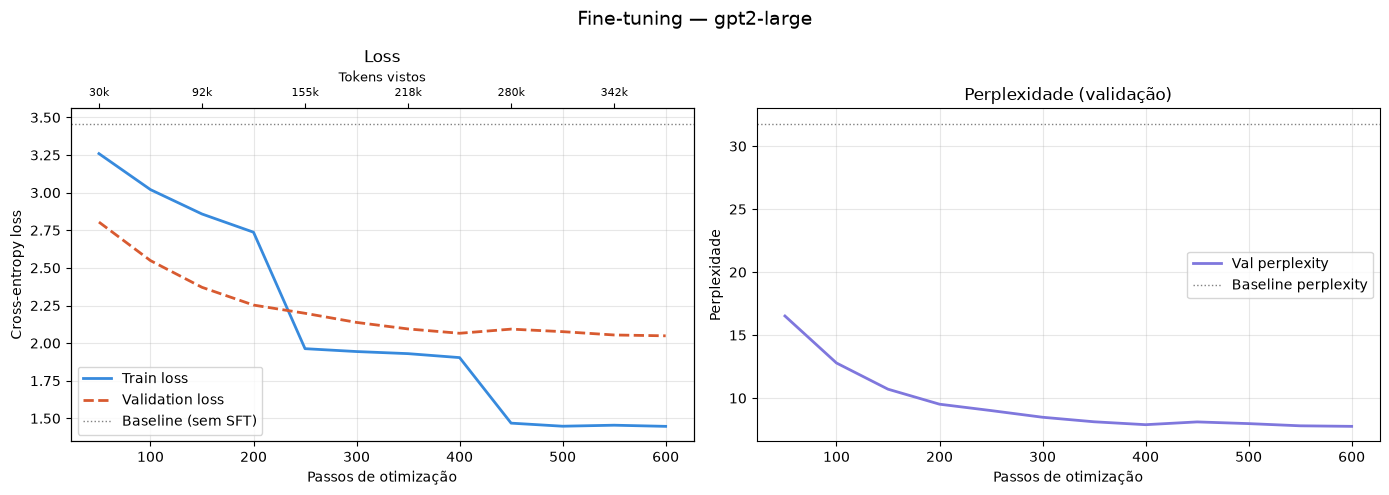

✅ Gráfico salvo em sft_model/training_curves.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Fine-tuning — {MODEL_NAME}", fontsize=14)

steps = history["steps"]

# ── Loss ──────────────────────────────────────────────────────────────────────
ax1.plot(steps, history["train_loss"], label="Train loss",      color="#378ADD", linewidth=2)
ax1.plot(steps, history["val_loss"],   label="Validation loss", color="#D85A30", linewidth=2,
         linestyle="--")
ax1.axhline(y=init_val_loss, color="gray", linestyle=":", linewidth=1, label="Baseline (sem SFT)")
ax1.set_xlabel("Passos de otimização")
ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# Eixo secundário com tokens vistos
if history["tokens_seen"]:
    ax1b = ax1.twiny()
    ax1b.set_xlim(ax1.get_xlim())
    tick_steps = steps[::max(1, len(steps)//5)]
    tick_tokens = [history["tokens_seen"][history["steps"].index(s)] // 1000
                   for s in tick_steps]
    ax1b.set_xticks(tick_steps)
    ax1b.set_xticklabels([f"{t}k" for t in tick_tokens], fontsize=8)
    ax1b.set_xlabel("Tokens vistos", fontsize=9)

# ── Perplexidade ──────────────────────────────────────────────────────────────
ax2.plot(steps, history["val_ppl"], color="#7F77DD", linewidth=2, label="Val perplexity")
ax2.axhline(y=math.exp(init_val_loss), color="gray", linestyle=":",
            linewidth=1, label="Baseline perplexity")
ax2.set_xlabel("Passos de otimização")
ax2.set_ylabel("Perplexidade")
ax2.set_title("Perplexidade (validação)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo em sft_model/training_curves.png")

## 10. Avaliação no conjunto de teste

Carrega o melhor checkpoint e avalia no test set.

In [12]:
# Carrega melhor checkpoint
best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state"])
print(f"✅ Melhor checkpoint carregado (época {best_ckpt['epoch']}, "
      f"step {best_ckpt['global_step']}, val_loss={best_ckpt['val_loss']:.4f})")

test_loss, test_ppl = evaluate(model, test_loader)

print(f"\n── Resultado final no conjunto de TESTE ─────────")
print(f"   test_loss   : {test_loss:.4f}")
print(f"   perplexidade: {test_ppl:.2f}")
print(f"   baseline ppl: {math.exp(init_val_loss):.2f}")
print(f"   melhora     : {(1 - test_ppl/math.exp(init_val_loss))*100:.1f}%")

✅ Melhor checkpoint carregado (época 3, step 600, val_loss=2.0485)


C:\Users\raffa\AppData\Local\Temp\ipykernel_23816\880620206.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_FP16 and DEVICE.type=="cuda")):



── Resultado final no conjunto de TESTE ─────────
   test_loss   : 1.9999
   perplexidade: 7.39
   baseline ppl: 31.80
   melhora     : 76.8%


## 11. Comparação antes × depois (avaliação qualitativa)

In [13]:
print("=" * 60)
print("COMPARAÇÃO ANTES × DEPOIS DO FINE-TUNING")
print("=" * 60)

finetuned_responses = []
for item in baseline_responses:
    q    = item["question"]
    bef  = item["response"]
    aft  = generate_response(model, tokenizer, q)
    finetuned_responses.append({"question": q, "before": bef, "after": aft})

    print(f"\nQ: {q}")
    print(f"\n[ANTES]\n{bef[:400]}{'...' if len(bef)>400 else ''}")
    print(f"\n[DEPOIS]\n{aft[:400]}{'...' if len(aft)>400 else ''}")
    print("-" * 60)

# Salva comparação
(OUTPUT_DIR / "qualitative_comparison.json").write_text(
    json.dumps(finetuned_responses, ensure_ascii=False, indent=2)
)
print("\n✅ Comparação salva em sft_model/qualitative_comparison.json")

COMPARAÇÃO ANTES × DEPOIS DO FINE-TUNING

Q: O que é uma árvore AVL e por que ela é preferida em relação a uma BST simples?

[ANTES]
The question is: how can we use this to improve the quality of the code?
Avanto único em relação de um relação
Avanto que é uma AVL e por que ela é preferida em relação a uma BST simples?
Avanto que é uma AVL e por que ela é preferida em relação a uma BST simples?
Avanto que é uma AVL e por que ela é preferida em relação a uma BST simples?
Avanto que é uma AVL e por que ela é preferida em relação ...

[DEPOIS]
Uma árvore AVL é preferida quando se busca nós de uma estrutura de dados em relação a um único nó de busca, geralmente sem a árvore específica. Isso é comumente mais eficiente em termos de busca, mas não depende da árvore AVL.
------------------------------------------------------------

Q: Explique o algoritmo QuickSort e sua complexidade de tempo.

[ANTES]
The search for a simple, short, and easy to understand algorithm.
Explique o algoritmo Quick

## 12. Salva modelo e tokenizer finais

In [14]:
# Salva no formato HuggingFace (compatível com pipeline, LoRA, etc.)
model.save_pretrained(OUTPUT_DIR / "hf_model")
tokenizer.save_pretrained(OUTPUT_DIR / "hf_model")

# Salva métricas finais
metrics = {
    "model":             MODEL_NAME,
    "epochs":            NUM_EPOCHS,
    "batch_size":        BATCH_SIZE,
    "grad_accum_steps":  GRAD_ACCUM_STEPS,
    "effective_batch":   BATCH_SIZE * GRAD_ACCUM_STEPS,
    "learning_rate":     LEARNING_RATE,
    "baseline_val_loss": round(init_val_loss, 4),
    "baseline_ppl":      round(math.exp(init_val_loss), 2),
    "best_val_loss":     round(best_val_loss, 4),
    "test_loss":         round(test_loss, 4),
    "test_ppl":          round(test_ppl, 2),
    "ppl_improvement_%": round((1 - test_ppl/math.exp(init_val_loss))*100, 1),
    "training_time_min": round(total_time, 1),
    "total_tokens_seen": tokens_seen,
    "train_samples":     len(train_data),
    "val_samples":       len(val_data),
    "test_samples":      len(test_data),
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))

print("✅ Modelo salvo em sft_model/hf_model/")
print("\n── Métricas finais ──────────────────────────────")
for k, v in metrics.items():
    print(f"   {k:<25} : {v}")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.31s/it]

✅ Modelo salvo em sft_model/hf_model/

── Métricas finais ──────────────────────────────
   model                     : gpt2-large
   epochs                    : 3
   batch_size                : 2
   grad_accum_steps          : 2
   effective_batch           : 4
   learning_rate             : 5e-05
   baseline_val_loss         : 3.4593
   baseline_ppl              : 31.8
   best_val_loss             : 2.0485
   test_loss                 : 1.9999
   test_ppl                  : 7.39
   ppl_improvement_%         : 76.8
   training_time_min         : 198.7
   total_tokens_seen         : 395580
   train_samples             : 850
   val_samples               : 100
   test_samples              : 50


---
## Resumo do pipeline

```
sft_artifacts/
  processed_dataset.pt    ← tensores prontos (do notebook anterior)
  tokenizer/              ← GPT-2 + tokens especiais Phi-3
      │
      ▼
  GPT-2 Large (774 M)
  resize_token_embeddings()   ← acomoda <|user|> e <|assistant|>
      │
      ▼
  AdamW + linear warmup/decay
  float16 + gradient accumulation (batch efetivo = 8)
  gradient clipping (norm 1.0)
      │
      ▼
  cross_entropy(logits, target_ids)   ← ignora -100 automaticamente
      │
      ▼
  checkpoint salvo a cada val_loss mínimo
      │
      ▼
sft_model/
  best_model.pt            ← melhor checkpoint durante treino
  hf_model/                ← formato HuggingFace (para LoRA, etc.)
  training_curves.png      ← loss e perplexidade
  qualitative_comparison.json
  metrics.json
```